# EDA — Fake Social Media Global 2.0 (with missing values)

**File:** `data/fake_social_media_global_2.0_with_missing.xlsx`

This dataset contains engineered social-media account features with a binary
target **`is_fake`** (1 = fake account, 0 = real account). It is the
modeling-ready dataset for the fake-account detection task.

Plan:
1. Load and first look
2. Missing values
3. Duplicates
4. Target analysis (class balance)
5. Numeric feature analysis
6. Categorical features
7. Feature behaviour by class + correlation with target
8. Key observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../data/fake_social_media_global_2.0_with_missing.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
df.head()

Rows: 3,000  Columns: 24


,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
0,X,1.0,180.0,1.0,431.0,679.0,0.633824,NaN,NaN,0.205945,0.699444,0.579354,456.0,NaN,5.0,1.0,0.0,0,dmitri,6,0,0.000000,0,0
1,NaN,1.0,214.0,NaN,426.0,729.0,0.583562,3164.0,202.0,0.063823,NaN,0.102866,98.0,NaN,141.0,NaN,1.0,1,smpni6240,9,4,0.444444,0,0
2,X,1.0,87.0,NaN,426.0,721.0,0.590028,903.0,225.0,0.248894,0.858450,0.310863,136.0,171.0,62.0,1.0,0.0,1,qgph5q343j,10,4,0.400000,0,0
3,X,0.0,72.0,0.0,385.0,NaN,0.566176,3433.0,175.0,0.050961,0.176471,0.076058,186.0,46.0,117.0,1.0,1.0,0,mia,3,0,0.000000,0,0
4,Instagram,0.0,162.0,NaN,392.0,709.0,0.552113,NaN,207.0,0.162992,0.265957,0.556130,35.0,184.0,64.0,NaN,1.0,0,martin,6,0,0.000000,0,0


## 1. First look — structure, dtypes, samples

In [2]:
df.info()
df.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  2667 non-null   str    
 1   has_profile_pic           2655 non-null   float64
 2   bio_length                2671 non-null   float64
 3   username_randomness       2663 non-null   float64
 4   followers                 2662 non-null   float64
 5   following                 2667 non-null   float64
 6   follower_following_ratio  2644 non-null   float64
 7   account_age_days          2657 non-null   float64
 8   posts                     2683 non-null   float64
 9   posts_per_day             2689 non-null   float64
 10  caption_similarity_score  2670 non-null   float64
 11  content_similarity_score  2672 non-null   float64
 12  follow_unfollow_rate      2692 non-null   float64
 13  spam_comments_rate        2662 non-null   float64
 14  generic_comment_rat

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
1801,Facebook,0.0,45.0,0.0,405.0,724.0,NaN,904.0,196.0,0.216575,0.094620,0.558941,439.0,NaN,85.0,1.0,1.0,1,acc_u0lk9vse,12,2,0.166667,1,1
1190,Instagram,0.0,28.0,1.0,392.0,710.0,0.551336,1005.0,230.0,0.228628,0.540781,0.870037,189.0,154.0,12.0,0.0,0.0,0,anna_9797,9,4,0.444444,1,1
1817,X,0.0,24.0,1.0,410.0,NaN,0.603829,3312.0,211.0,0.063688,0.898189,NaN,137.0,18.0,NaN,0.0,0.0,1,164w6457o8,10,8,0.800000,0,0
251,X,0.0,176.0,1.0,403.0,677.0,0.594395,2206.0,203.0,0.091980,0.030437,0.680003,208.0,80.0,55.0,1.0,0.0,0,satish_6210,11,4,0.363636,1,0
2505,NaN,1.0,64.0,0.0,369.0,678.0,0.543446,962.0,200.0,0.207684,0.186578,NaN,187.0,192.0,65.0,1.0,NaN,0,liwei,5,0,0.000000,0,0


## 2. Missing values

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
print(f"Columns with missing values: {len(missing_tbl)} / {df.shape[1]}")
missing_tbl


Columns with missing values: 17 / 24


,missing_count,missing_pct
generic_comment_rate,367,12.23
suspicious_links_in_bio,360,12.00
follower_following_ratio,356,11.87
has_profile_pic,345,11.50
account_age_days,343,11.43
followers,338,11.27
spam_comments_rate,338,11.27
verified,337,11.23
username_randomness,337,11.23
platform,333,11.10


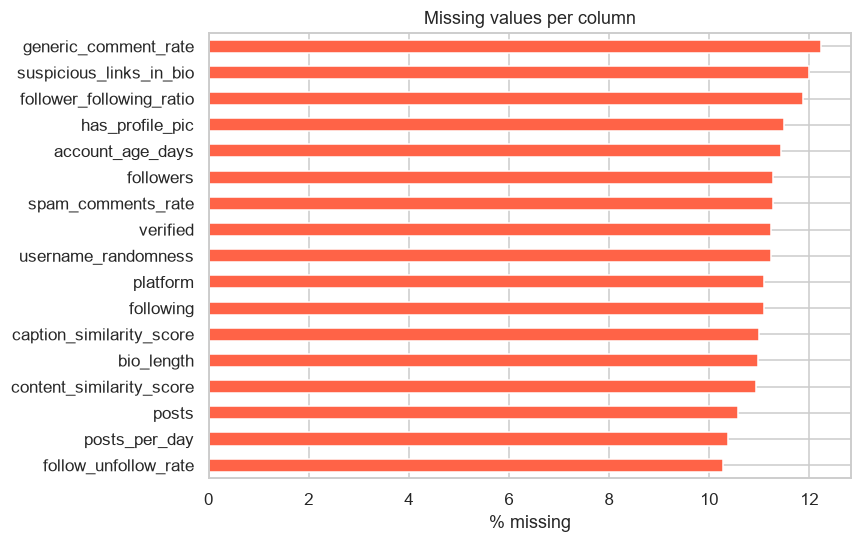

In [4]:
if missing_tbl.empty:
    print("No missing values in this dataset.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_tbl))))
    missing_tbl["missing_pct"].sort_values().plot.barh(ax=ax, color="tomato")
    ax.set_xlabel("% missing")
    ax.set_title("Missing values per column")
    plt.tight_layout()
    plt.show()


## 3. Duplicates

In [5]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
if "id" in df.columns:
    print(f"Duplicated 'id' values: {df['id'].duplicated().sum()}")
    print("Most frequent ids:")
    display(df["id"].value_counts().head(10))


Fully duplicated rows: 0


## 4. Target analysis — class balance

is_fake
0    1941
1    1059
Name: count, dtype: int64

Fraud rate: 35.30% fake accounts


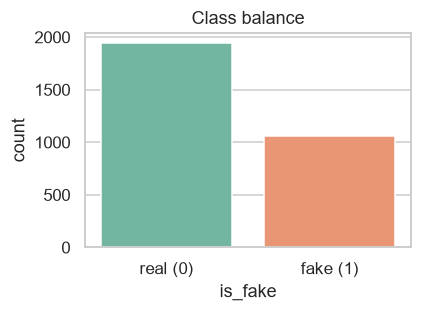

In [6]:
label_col = "is_fake"
counts = df[label_col].value_counts()
print(counts)
print(f"\nFraud rate: {df[label_col].mean() * 100:.2f}% fake accounts")

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x=label_col, data=df, ax=ax, hue=label_col, palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["real (0)", "fake (1)"])
ax.set_title("Class balance")
plt.tight_layout()
plt.show()


## 5. Numeric feature analysis

In [7]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns ({len(num_cols)}):")
display(df[num_cols].describe().T.round(3))


Numeric columns (22):


,count,mean,std,min,25%,50%,75%,max
has_profile_pic,2655.0,0.493,0.500,0.000,0.000,0.000,1.000,1.000
bio_length,2671.0,124.181,71.200,0.000,65.000,124.000,184.500,249.000
username_randomness,2663.0,0.503,0.500,0.000,0.000,1.000,1.000,1.000
followers,2662.0,399.984,20.082,334.000,387.000,400.000,413.000,472.000
following,2667.0,700.841,25.841,616.000,684.000,701.000,718.000,789.000
follower_following_ratio,2644.0,0.571,0.035,0.467,0.546,0.571,0.594,0.694
account_age_days,2657.0,2490.854,1436.751,2.000,1247.000,2455.000,3746.000,4997.000
posts,2683.0,200.296,14.234,151.000,190.000,200.000,209.000,254.000
posts_per_day,2689.0,0.274,1.693,0.035,0.054,0.081,0.161,73.333
caption_similarity_score,2670.0,0.503,0.286,0.000,0.260,0.511,0.749,0.999


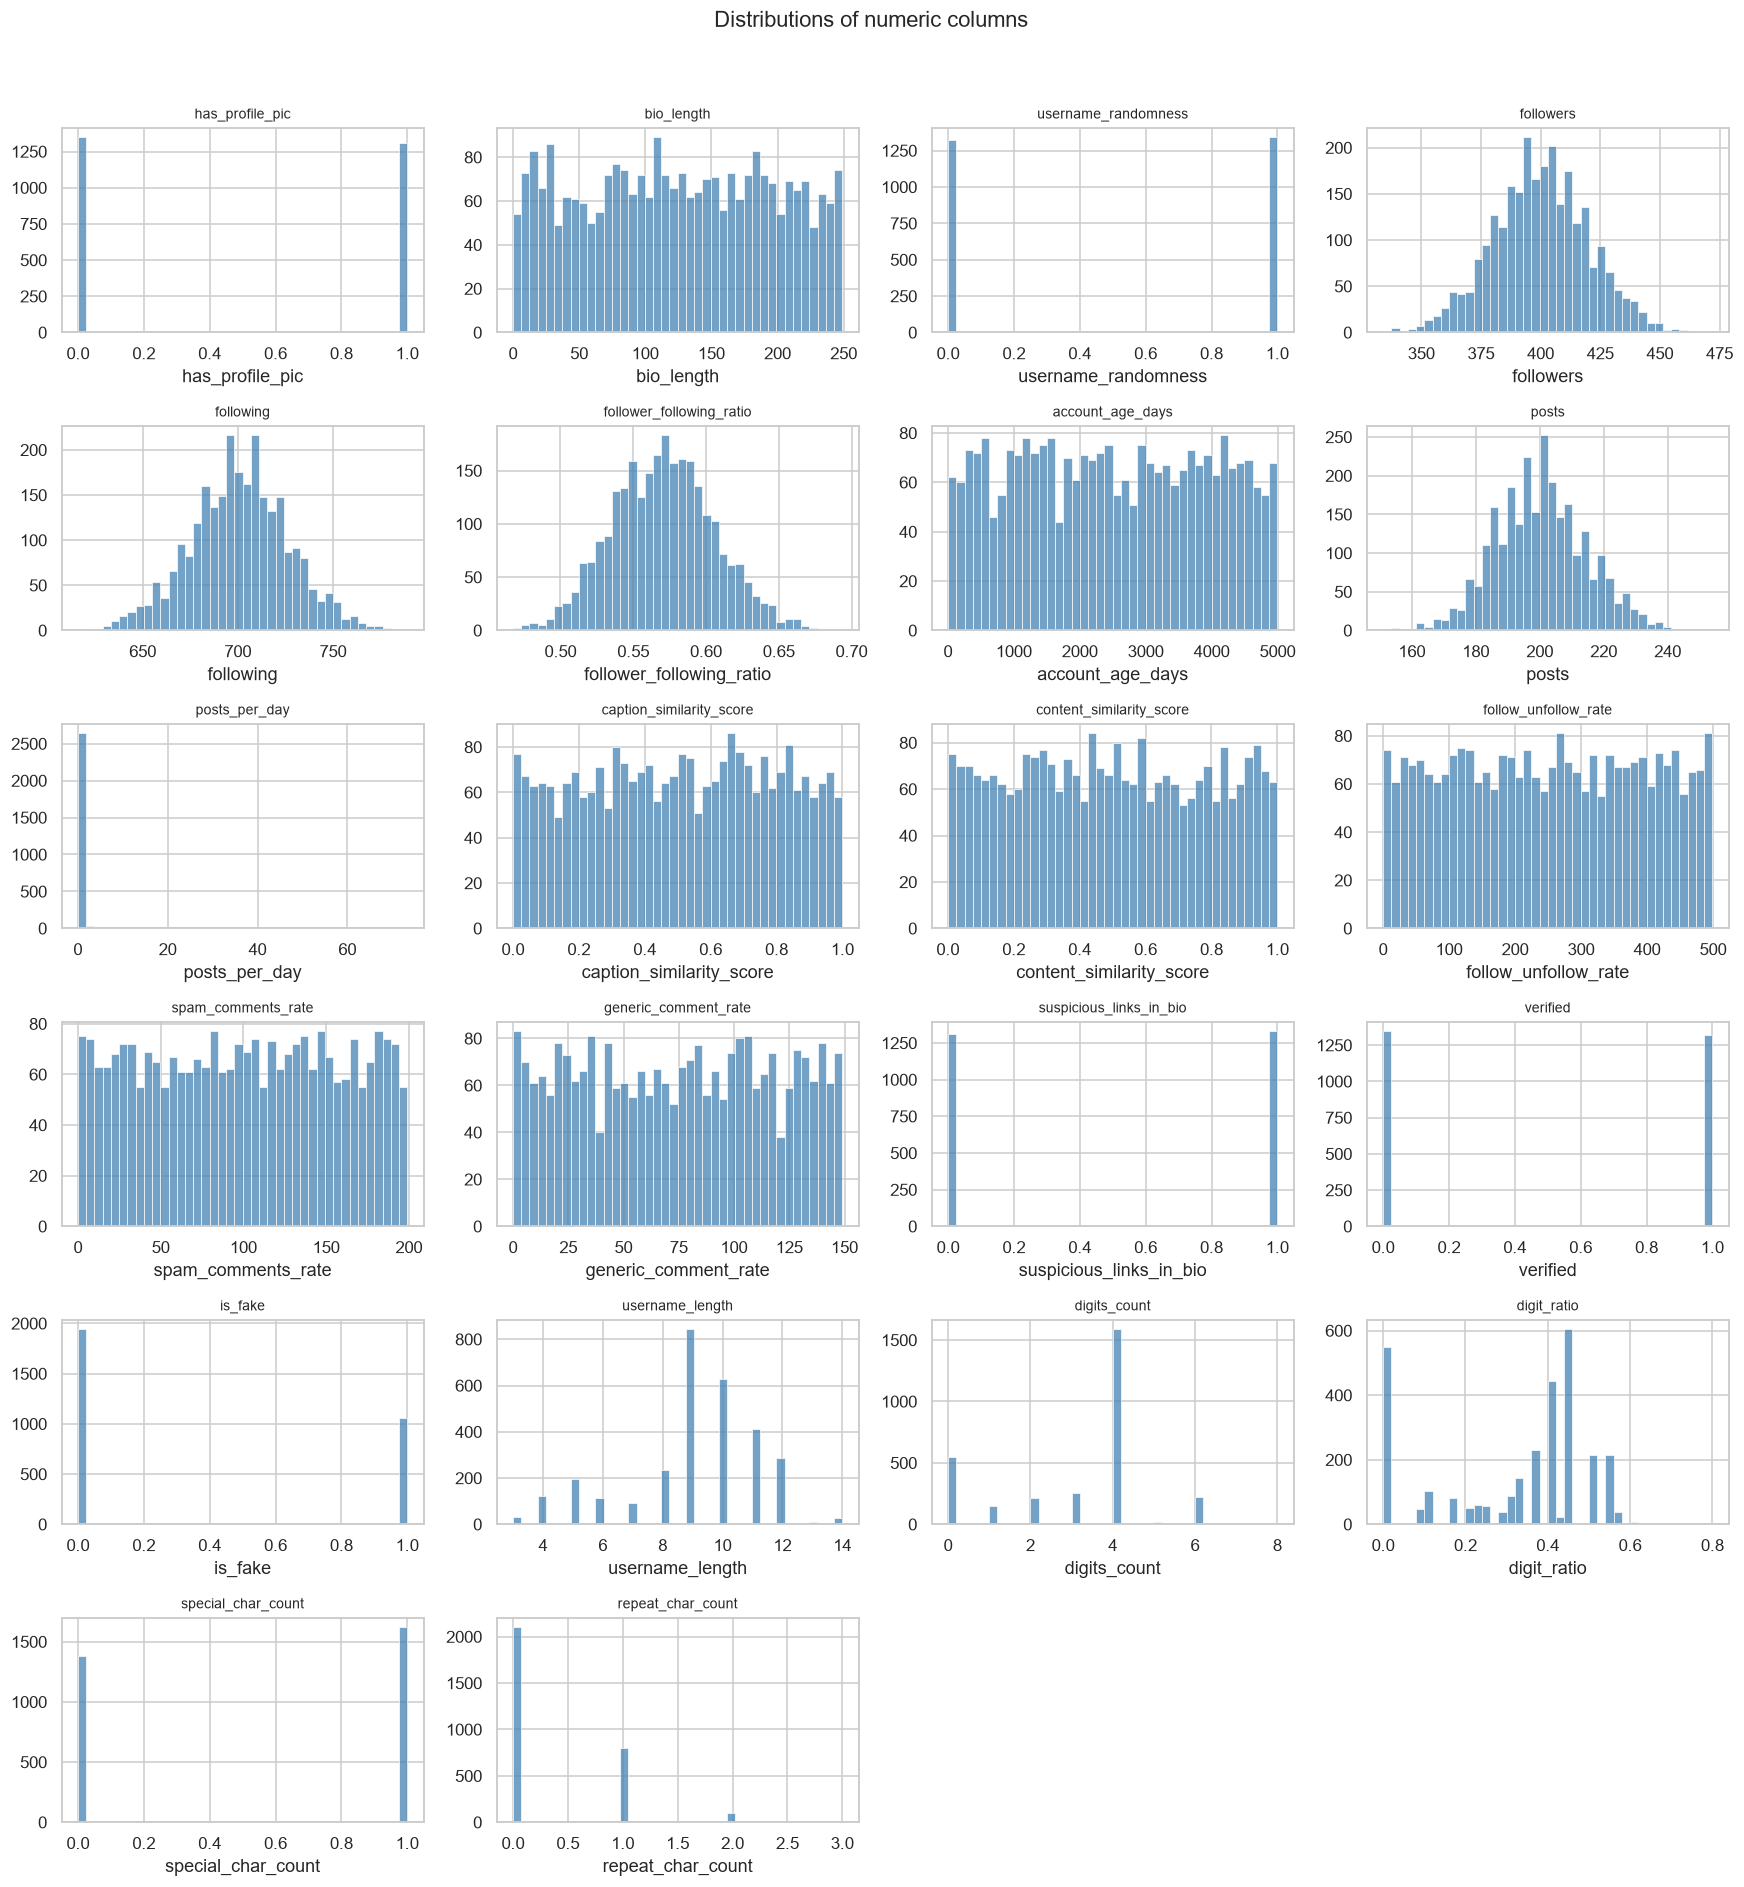

In [8]:
n = len(num_cols)
ncols = min(n, 4)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Distributions of numeric columns", y=1.02)
plt.tight_layout()
plt.show()


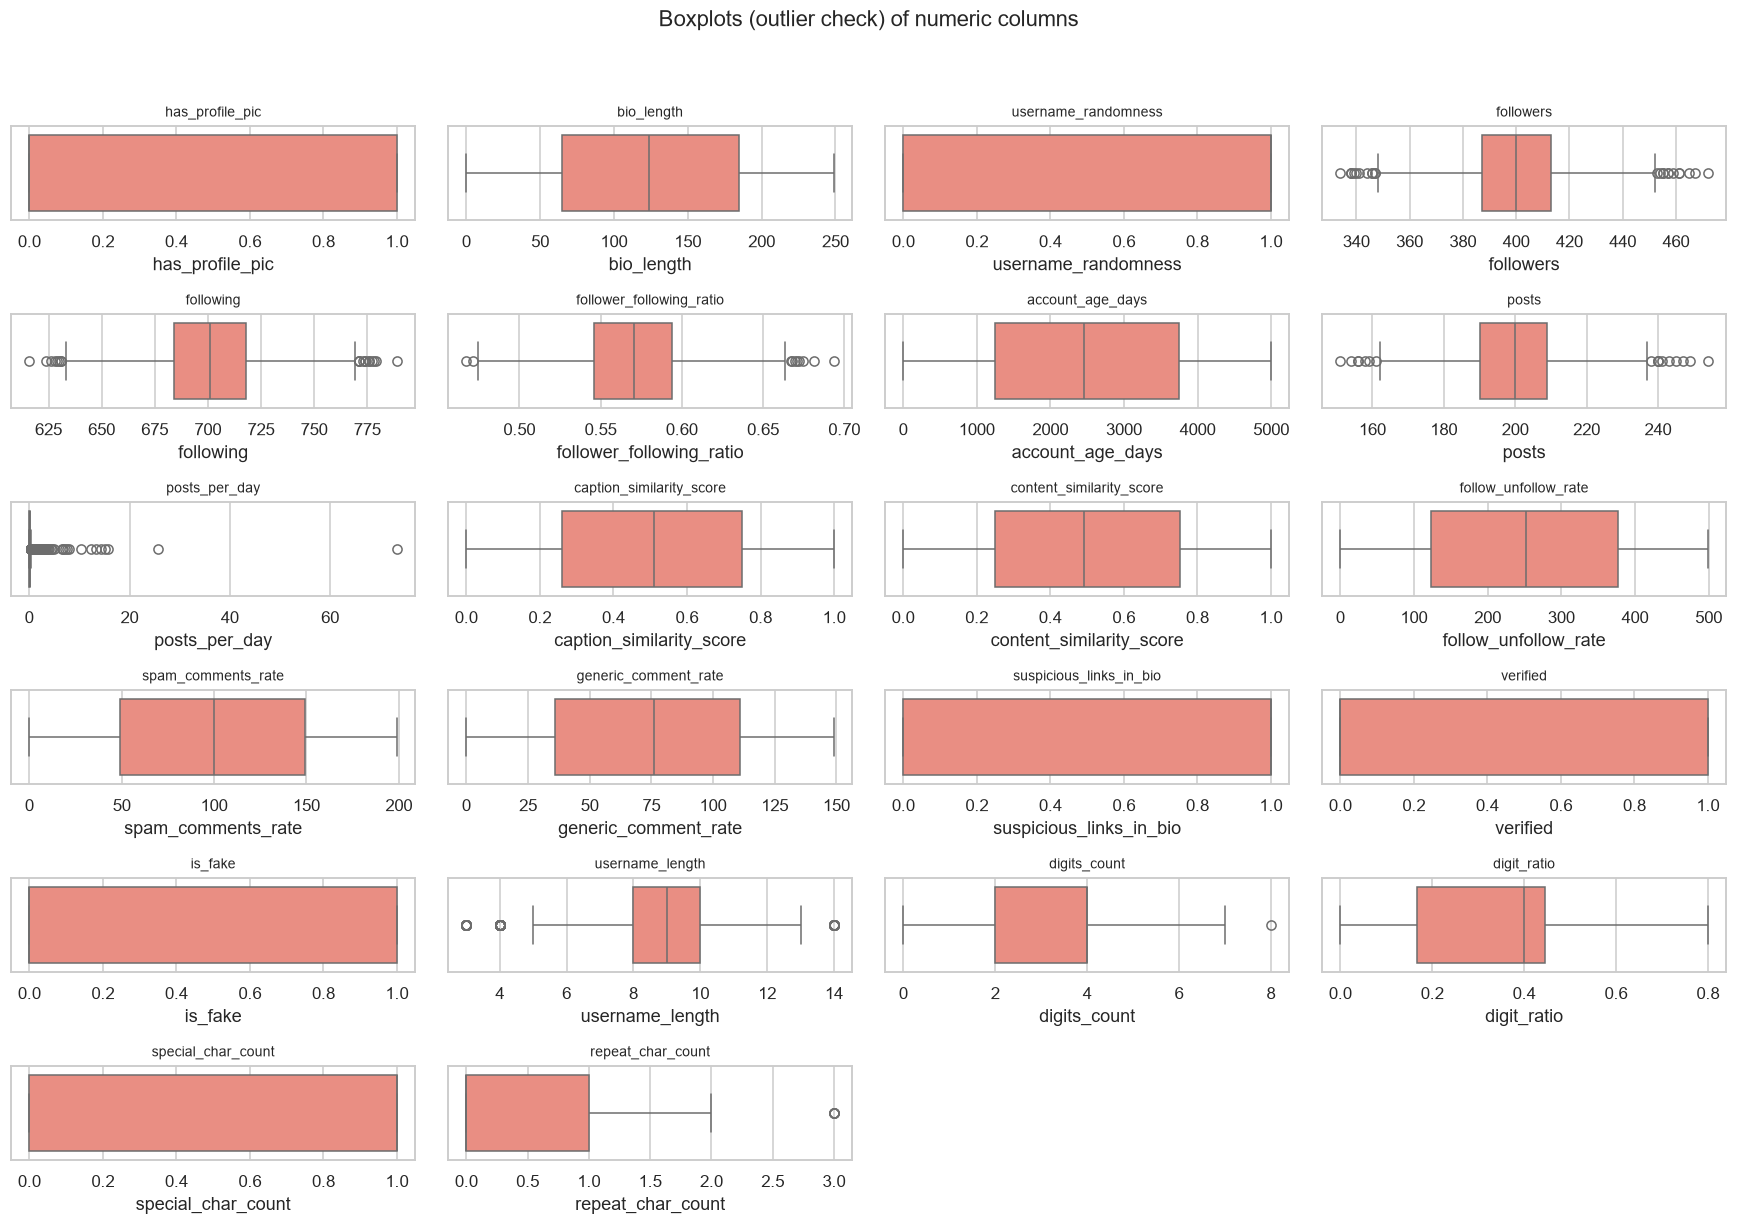

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 1.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="salmon")
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Boxplots (outlier check) of numeric columns", y=1.03)
plt.tight_layout()
plt.show()


## 6. Categorical features

In [10]:
cat_cols = [c for c in df.columns if c not in num_cols]
print(f"Non-numeric columns ({len(cat_cols)}):")
overview = pd.DataFrame({
    "nunique": [df[c].nunique(dropna=True) for c in cat_cols],
    "missing_pct": [round(df[c].isna().mean() * 100, 1) for c in cat_cols],
    "example": [str(df[c].dropna().iloc[0])[:60] if df[c].notna().any() else "-" for c in cat_cols],
}, index=cat_cols)
display(overview)


Non-numeric columns (2):


,nunique,missing_pct,example
platform,3,11.1,X
username,2579,0.0,dmitri


Low-cardinality categorical columns: ['platform']


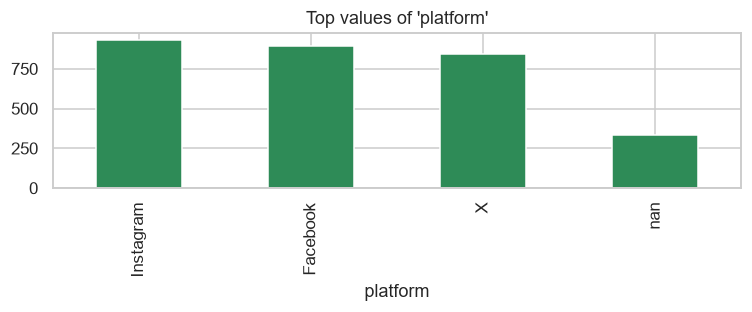

In [11]:
# Top values for the most informative low-cardinality categorical columns
low_card = [c for c in cat_cols if 1 < df[c].nunique(dropna=True) <= 30]
print("Low-cardinality categorical columns:", low_card)
for c in low_card[:8]:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[c].value_counts(dropna=False).head(15).plot.bar(ax=ax, color="seagreen")
    ax.set_title(f"Top values of '{c}'")
    plt.tight_layout()
    plt.show()


## 7. Features by class and correlation with target

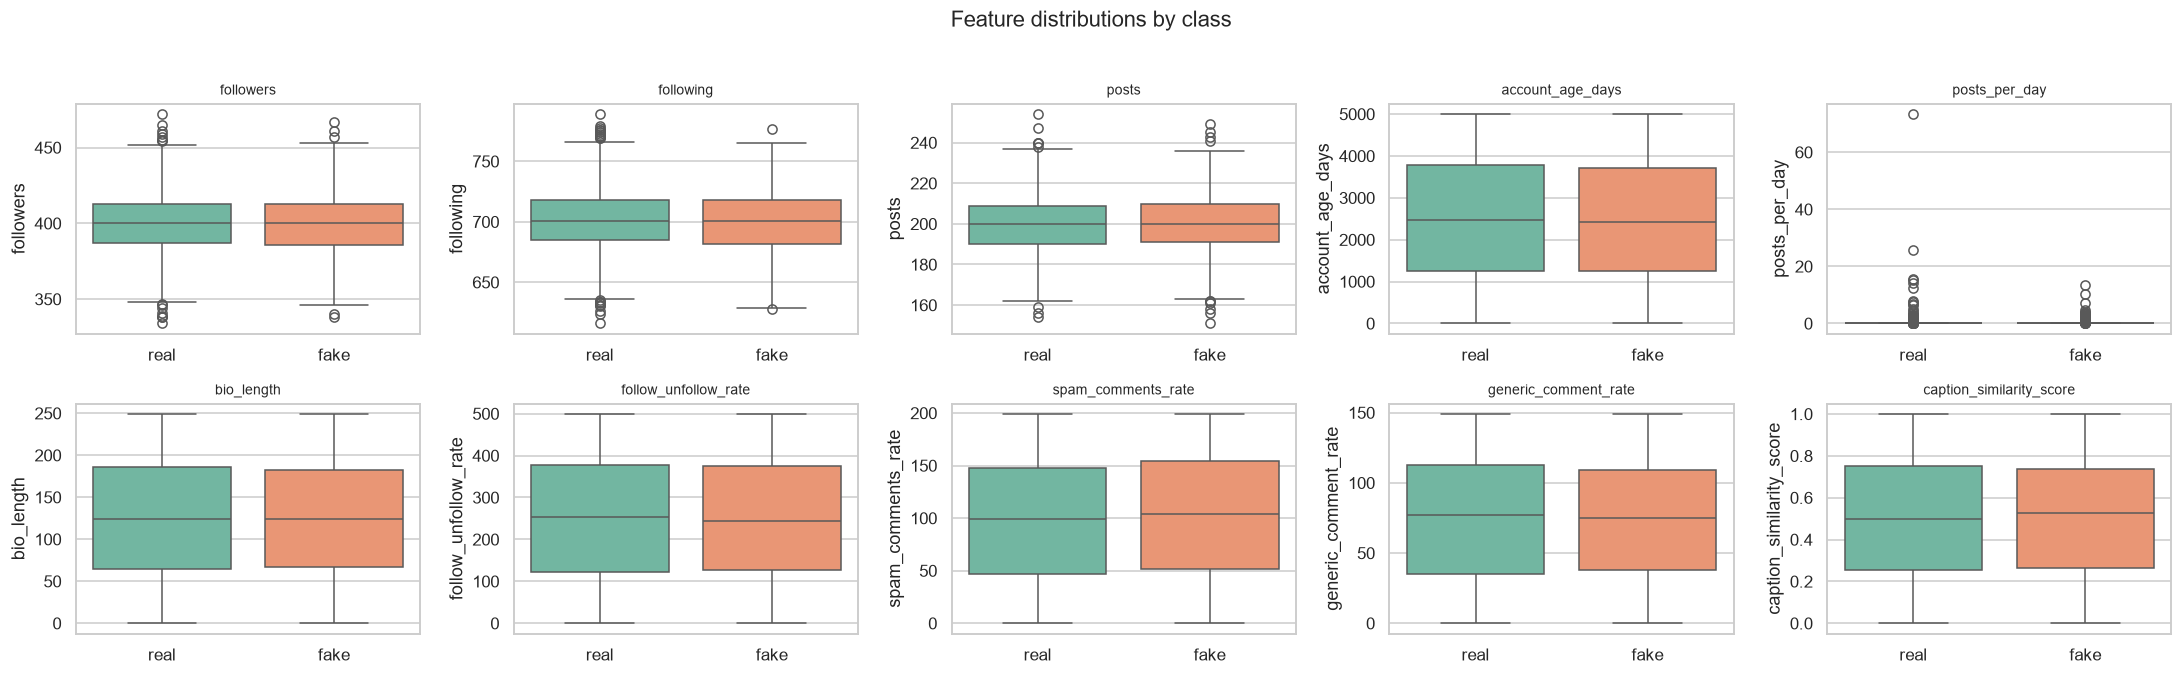

is_fake,0,1
has_profile_pic,0.493,0.492
bio_length,124.650,123.319
username_randomness,0.508,0.494
followers,400.043,399.880
following,701.327,699.969
follower_following_ratio,0.570,0.572
account_age_days,2500.590,2472.595
posts,200.260,200.361
posts_per_day,0.291,0.243
caption_similarity_score,0.501,0.508


In [12]:
# How do key features differ between real and fake accounts?
key_features = [
    "followers", "following", "posts", "account_age_days", "posts_per_day",
    "bio_length", "follow_unfollow_rate", "spam_comments_rate",
    "generic_comment_rate", "caption_similarity_score",
]
key_features = [c for c in key_features if c in df.columns]
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.ravel()
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x=label_col, y=col, hue=label_col, ax=ax,
                palette="Set2", legend=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["real", "fake"])
for ax in axes[len(key_features):]:
    ax.axis("off")
plt.suptitle("Feature distributions by class", y=1.02)
plt.tight_layout()
plt.show()

display(df.groupby(label_col)[num_cols].mean().T.round(3))


In [13]:
# Correlation of each feature with the target
target_corr = df[num_cols].corrwith(df[label_col]).sort_values(key=np.abs, ascending=False)
print(target_corr.round(3))


is_fake                     1.000
username_length             0.407
repeat_char_count           0.260
digits_count                0.111
special_char_count          0.094
spam_comments_rate          0.038
digit_ratio                 0.036
verified                   -0.032
follower_following_ratio    0.025
following                  -0.025
content_similarity_score    0.015
username_randomness        -0.013
posts_per_day              -0.013
caption_similarity_score    0.011
account_age_days           -0.009
bio_length                 -0.009
follow_unfollow_rate       -0.005
followers                  -0.004
suspicious_links_in_bio    -0.003
posts                       0.003
has_profile_pic            -0.001
generic_comment_rate       -0.001
dtype: float64


## 8. Key observations
- **3,000 rows x 24 columns**: the 18 social-media feature columns plus 6 **username-derived features** (`username`, `username_length`, `digits_count`, `digit_ratio`, `special_char_count`, `repeat_char_count`).
- **Deliberately injected missing values** in every feature column (~10-12%, ~310-370 cells each); `is_fake`, `username*` columns are complete. This notebook is the template for missing-value handling (imputation + missingness indicators).
- **Reasonably balanced target: 35.3% fake (1,059 fake / 1,941 real)** — suitable for supervised training with mild class weighting.
- 3 platforms: Instagram (928), Facebook (894), X (845), plus 333 missing.
- Username features show fake-typical patterns to verify by class: higher `digits_count`/`digit_ratio`, special characters.
- Same scale issues as the CSV version (`posts_per_day` outliers, unbounded rate features).
- **Modeling implications:** best candidate training set; needs imputation strategy (median/mode + indicators), scaling, and platform one-hot encoding.